In [ ]:
# %%
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
data_dir = "../das_data/noise_data"
files = sorted([f for f in os.listdir(data_dir) if f.endswith(".h5")])
print(f"Found {len(files)} files in directory.")
if len(files) > 0:
    print("Example files:", files[:5])

Found 166 files in directory.
Example files: ['NCSN73765585.0.h5', 'NCSN73773465.0.h5', 'NCSN73774300.0.h5', 'NCSN73781306.0.h5', 'NCSN73799091.0.h5']


In [ ]:
# %%
# ====== Select one file to inspect ======

file_name = "ci39812319-2.h5"
file_path = os.path.join(data_dir, file_name)
print(f"\nReading file: {file_path}")

# %%
# ====== Read HDF5 content ======
with h5py.File(file_path, "r") as f:
    data = f["data"][:]  # shape: [channels, time_samples]
    attrs = dict(f["data"].attrs)

print(f"Data shape: {data.shape} (channels × time samples)")
print("Attributes:")
for k, v in attrs.items():
    print(f"  {k}: {v}")

# %%
# ====== Build time axis ======
dt = float(attrs.get("dt_s", 0.005))
t = np.arange(data.shape[1]) * dt
print(f"Sampling interval dt = {dt:.6f} s, total duration = {t[-1]:.2f} s")

# %%
# ====== Basic statistics ======
mean_val = np.mean(data)
std_val = np.std(data)
print(f"Mean: {mean_val:.4f}, Std: {std_val:.4f}")
print(f"Max: {np.max(data):.4f}, Min: {np.min(data):.4f}")


Reading file: ./noise_data/ci39812319-2.h5
Data shape: (4994, 2500) (channels × time samples)
Attributes:
  dt_s: 0.01
  end_idx: 2952
  event_id: ci39812319
  start_idx: 452
  window_type: background
  y_max: 4994
  y_min: 1
Sampling interval dt = 0.010000 s, total duration = 24.99 s
Mean: 0.0000, Std: 0.0043
Max: 0.0716, Min: -0.0723


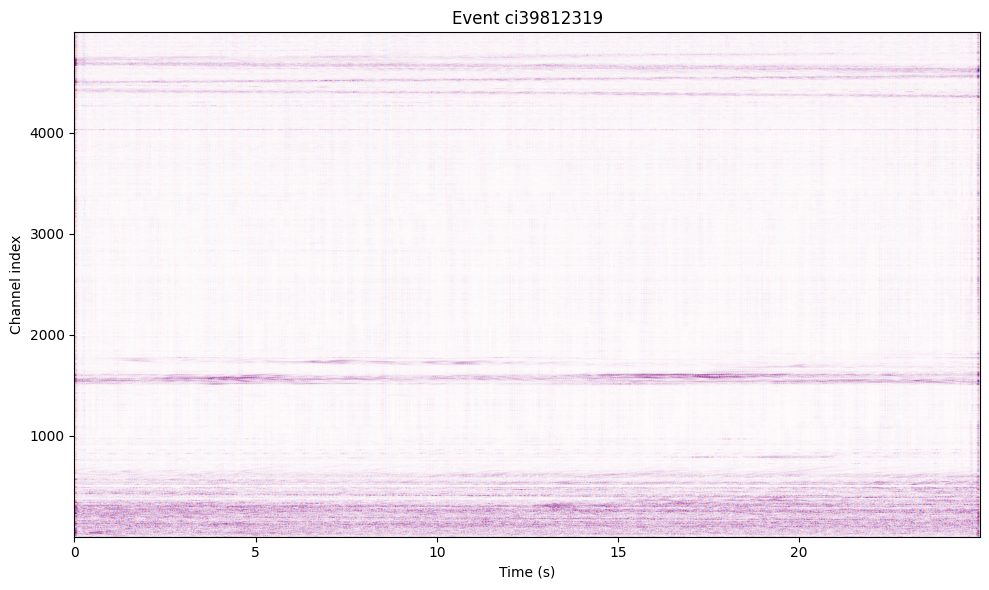

In [ ]:
# ====== Plot the signal ======
plt.figure(figsize=(10, 6))
plt.imshow(
    data,
    aspect="auto",
    cmap="seismic",
    origin="lower",
    extent=[t[0], t[-1], attrs.get("y_min", 0), attrs.get("y_max", data.shape[0])],
)
plt.title(f"Event {attrs.get('event_id', '?')}")
plt.xlabel("Time (s)")
plt.ylabel("Channel index")
plt.tight_layout()
plt.show()

Filtered with 2–10 Hz bandpass, clipped at 95.0th percentile.


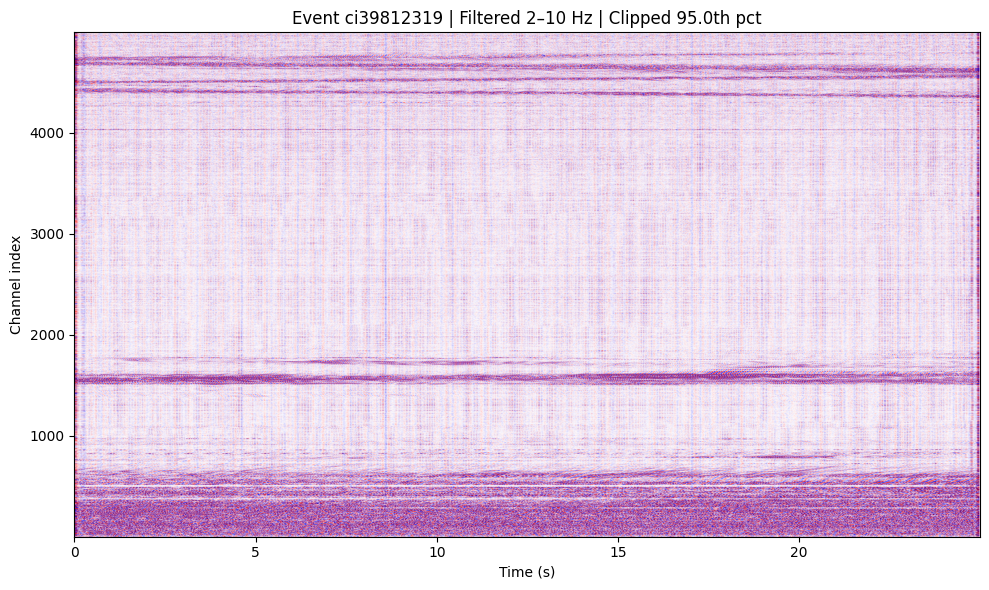

In [9]:
# %%
# ====== Filter and clip the data, then plot again ======
from scipy.signal import butter, sosfiltfilt

def bandpass(data, fs, lowcut=2, highcut=10, order=4):
    """Apply a Butterworth bandpass filter to 2D data (channels × time)."""
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, data, axis=1)

# bandpass filter
fs = 1.0 / float(attrs.get("dt_s", 0.005))
clip_percent = 95.0
band = [2, 10]  # Hz

# clip
clip_val = np.percentile(np.abs(data), clip_percent)
data_clip = np.clip(data, -clip_val, clip_val)

data_filt = bandpass(data_clip, fs, *band)

print(f"Filtered with {band[0]}–{band[1]} Hz bandpass, clipped at {clip_percent}th percentile.")

# plot filtered data
plt.figure(figsize=(10, 6))
plt.imshow(
    data_filt,
    aspect="auto",
    cmap="seismic",
    origin="lower",
    extent=[t[0], t[-1], attrs.get("y_min", 0), attrs.get("y_max", data.shape[0])],
)
plt.title(
    f"Event {attrs.get('event_id', '?')} | Filtered {band[0]}–{band[1]} Hz | Clipped {clip_percent}th pct"
)
plt.xlabel("Time (s)")
plt.ylabel("Channel index")
plt.tight_layout()
plt.show()
